In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/clip1_30s_tracks.csv")
df.head()

car = df[df.track_id == 4].sort_values("time_s")

#Computing time to collision
car["w_smooth"] = car["w"].rolling(15, center=True).mean()

# Growth rate in pixels per second
car["dw_dt"] = np.gradient(car["w_smooth"], car["time_s"])

# TTC only means something when the box is growing (we're closing)
car["ttc"] = np.where(car["dw_dt"] > 0, car["w_smooth"] / car["dw_dt"], np.nan)


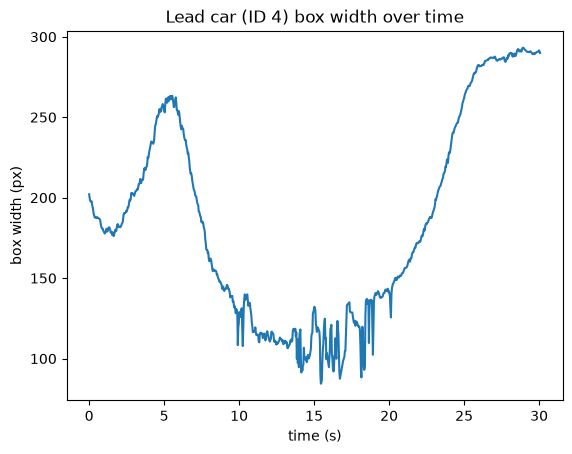

In [2]:
plt.plot(car["time_s"], car["w"])
plt.xlabel("time (s)")
plt.ylabel("box width (px)")
plt.title("Lead car (ID 4) box width over time")
plt.show()


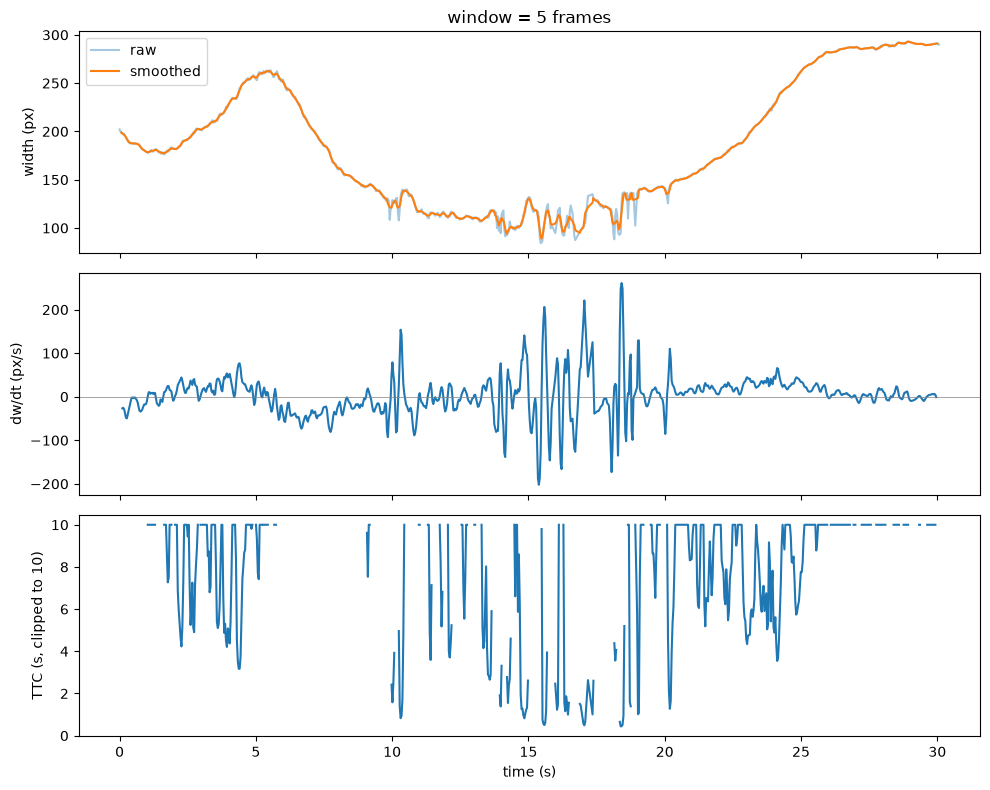

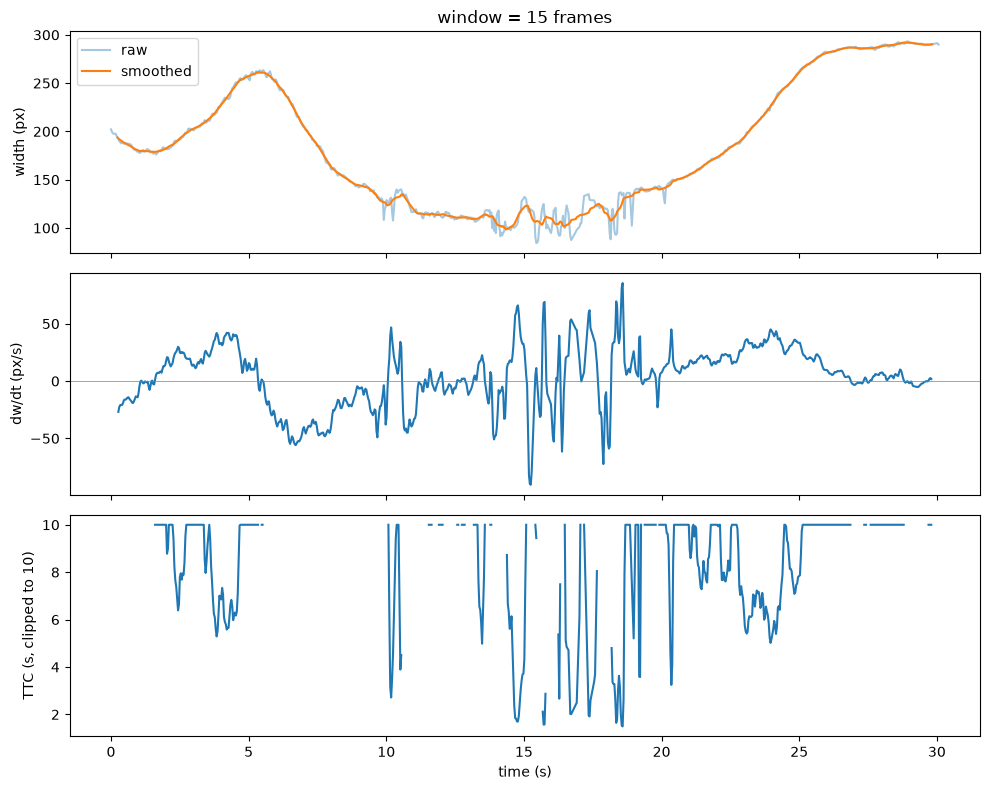

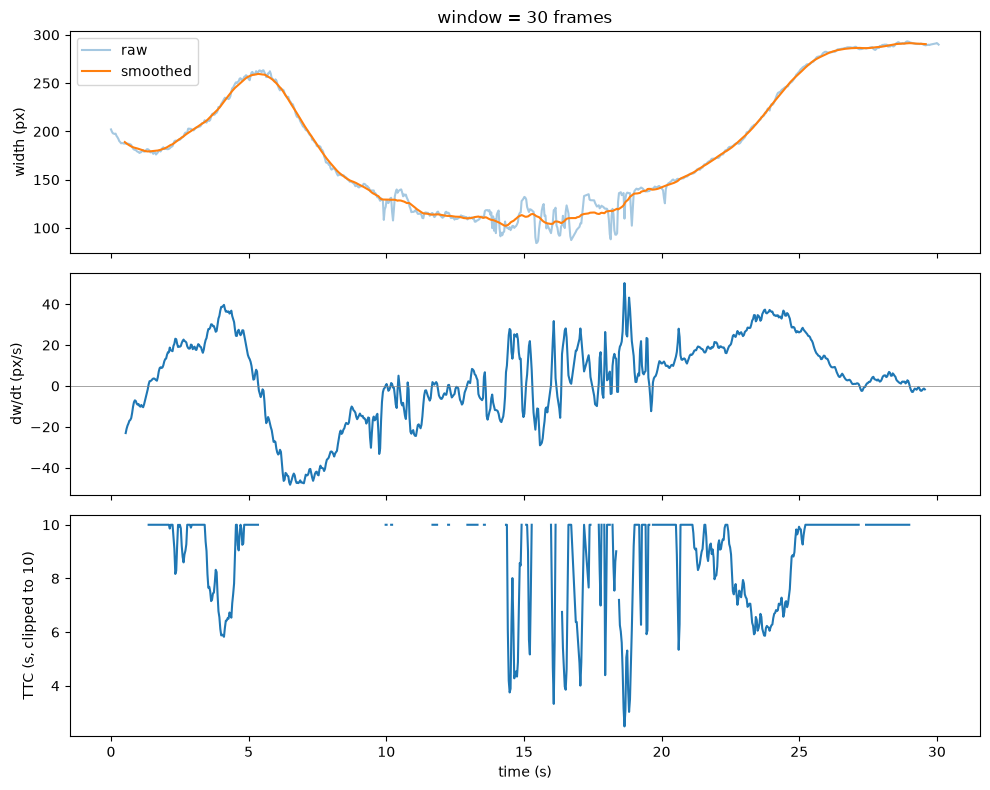

In [3]:
def plot_ttc(car, window):
    c = car.copy()
    c["w_smooth"] = c["w"].rolling(window, center=True).mean()
    c["dw_dt"] = np.gradient(c["w_smooth"], c["time_s"])
    c["ttc"] = np.where(c["dw_dt"] > 0, c["w_smooth"] / c["dw_dt"], np.nan)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(c["time_s"], c["w"], alpha=0.4, label="raw")
    axes[0].plot(c["time_s"], c["w_smooth"], label="smoothed")
    axes[0].set_ylabel("width (px)")
    axes[0].legend()
    axes[0].set_title(f"window = {window} frames")

    axes[1].plot(c["time_s"], c["dw_dt"])
    axes[1].axhline(0, color="gray", linewidth=0.5)
    axes[1].set_ylabel("dw/dt (px/s)")

    axes[2].plot(c["time_s"], c["ttc"].clip(upper=10))
    axes[2].set_ylabel("TTC (s, clipped to 10)")
    axes[2].set_xlabel("time (s)")

    plt.tight_layout()
    plt.show()
    return c

for window in (5, 15, 30):
    plot_ttc(car, window)


In [4]:
# Diagnostic: is this track continuous, or does it have gaps where the
# detector missed the car for a few frames?
frame_gaps = car["frame"].diff()
print("Frame count:", len(car))
print("Frame span:", car["frame"].max() - car["frame"].min() + 1)
print("Gaps > 1 frame:", (frame_gaps > 1).sum())
print(frame_gaps.value_counts().sort_index())


Frame count: 875
Frame span: 902
Gaps > 1 frame: 15
frame
1.0    859
2.0      9
3.0      2
4.0      2
5.0      2
Name: count, dtype: int64


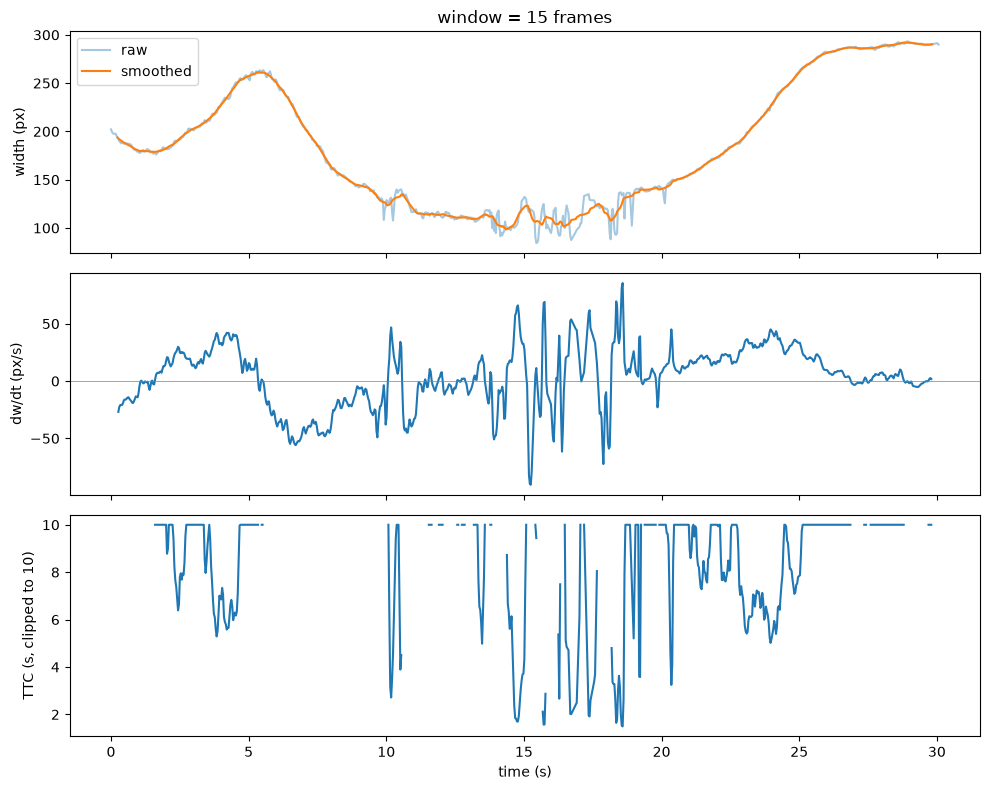

dw_dt sign flips: 67 over 875 frames
Fraction of frames with dw_dt near zero (|dw_dt| < 5 px/s): 0.18514285714285714
Fraction of frames with usable (non-nan) TTC: 0.5794285714285714


In [5]:
# Diagnostic: how often does dw_dt flip sign (steady-state noise), and
# what fraction of the track has usable (non-nan) TTC?
c = plot_ttc(car, 15)  # reuse the window=15 computation from the function

sign = np.sign(c["dw_dt"])
sign_flips = (sign.diff() != 0).sum()
print("dw_dt sign flips:", sign_flips, "over", len(c), "frames")
print("Fraction of frames with dw_dt near zero (|dw_dt| < 5 px/s):",
      (c["dw_dt"].abs() < 5).mean())
print("Fraction of frames with usable (non-nan) TTC:", c["ttc"].notna().mean())


In [6]:
# --- Kalman filter, step 1: state ---
#
# The filter tracks two numbers ("the state") at every frame:
#   x[0] = width estimate (px)
#   x[1] = rate estimate, i.e. dw/dt (px/s)
#
# We also track how *uncertain* we are about that state, as a 2x2
# covariance matrix P. Big P = "I don't trust this estimate yet."
# Initialize width to the first real measurement, rate to 0 (no
# information yet), and uncertainty high since we're just guessing.

widths = car["w"].to_numpy()
times = car["time_s"].to_numpy()

x = np.array([widths[0], 0.0])   # initial state: [width, rate]
P = np.eye(2) * 100.0            # initial uncertainty: fairly unsure

print("Initial state (width, rate):", x)
print("Initial uncertainty:\n", P)


Initial state (width, rate): [202.1   0. ]
Initial uncertainty:
 [[100.   0.]
 [  0. 100.]]


In [7]:
# --- Kalman filter, step 2: predict (just once, for frame 0 -> frame 1) ---
#
# F: "constant velocity" model.
#   new_width = width + rate * dt
#   new_rate  = rate                (we assume rate stays the same;
#                                     Q below is how much we allow it to drift)
#
# Q: process noise. We scale it by dt because the longer we go without a
# measurement (e.g. during a frame gap), the more the true rate could have
# drifted, so we should trust our own prediction less over larger gaps.

dt = times[1] - times[0]

F = np.array([[1.0, dt],
              [0.0, 1.0]])

q_width = 1.0   # how much width itself can drift unexplained, per second
q_rate = 50.0   # how much the rate can drift unexplained, per second (this one matters more)
Q = np.array([[q_width * dt, 0.0],
              [0.0,          q_rate * dt]])

x_pred = F @ x
P_pred = F @ P @ F.T + Q

print("dt:", dt)
print("Predicted state (width, rate):", x_pred)
print("Predicted uncertainty:\n", P_pred)


dt: 0.033
Predicted state (width, rate): [202.1   0. ]
Predicted uncertainty:
 [[100.1419   3.3   ]
 [  3.3    101.65  ]]


In [8]:
# --- Kalman filter, step 3: update (fold in the frame-1 measurement) ---
#
# H picks width out of the state [width, rate] -> we can only measure width.
# R is measurement noise: how much we expect a single box-width reading to
# jitter due to detector noise, independent of the car's real motion.

H = np.array([[1.0, 0.0]])
R = np.array([[25.0]])   # px^2 -- e.g. +-5px typical jitter

z = widths[1]                        # the new measurement
y = z - (H @ x_pred)[0]              # innovation: measured - predicted
S = (H @ P_pred @ H.T)[0, 0] + R[0, 0]   # innovation covariance
K = (P_pred @ H.T).flatten() / S     # Kalman gain (one weight per state var)

x_new = x_pred + K * y
P_new = (np.eye(2) - np.outer(K, H)) @ P_pred

print("Measurement:", z)
print("Innovation (measured - predicted):", y)
print("Kalman gain:", K)
print("Updated state (width, rate):", x_new)
print("Updated uncertainty:\n", P_new)


Measurement: 199.8
Innovation (measured - predicted): -2.299999999999983
Kalman gain: [0.80022678 0.02637006]
Updated state (width, rate): [ 2.00259478e+02 -6.06511488e-02]
Updated uncertainty:
 [[ 20.00566956   0.65925162]
 [  0.65925162 101.56297879]]


In [9]:
# --- Kalman filter, step 4: run it over the whole track ---
#
# Same predict + update math as above, just looped frame by frame, storing
# the state at every step. Reset x, P fresh (the cells above already
# advanced them by one step, we don't want to double-apply that).

x = np.array([widths[0], 0.0])
P = np.eye(2) * 100.0

n = len(widths)
w_kalman = np.zeros(n)
rate_kalman = np.zeros(n)
w_kalman[0], rate_kalman[0] = x

for i in range(1, n):
    dt = times[i] - times[i - 1]
    if dt <= 0:
        dt = 1 / 30  # guard against duplicate/out-of-order timestamps

    F = np.array([[1.0, dt],
                  [0.0, 1.0]])
    Q = np.array([[q_width * dt, 0.0],
                  [0.0,          q_rate * dt]])

    # predict
    x = F @ x
    P = F @ P @ F.T + Q

    # update
    z = widths[i]
    y = z - (H @ x)[0]
    S = (H @ P @ H.T)[0, 0] + R[0, 0]
    K = (P @ H.T).flatten() / S

    x = x + K * y
    P = (np.eye(2) - np.outer(K, H)) @ P

    w_kalman[i], rate_kalman[i] = x

car["w_kalman"] = w_kalman
car["rate_kalman"] = rate_kalman

# np.where evaluates w_kalman/rate_kalman everywhere (even where rate<=0),
# so divide-by-zero there is expected -- use np.divide's `where` so it only
# actually computes the division where it's valid, no warning.
ttc_kalman = np.full(n, np.nan)
np.divide(w_kalman, rate_kalman, out=ttc_kalman, where=rate_kalman > 0)
car["ttc_kalman"] = ttc_kalman

print("Kalman: dw/dt sign flips:", (np.sign(rate_kalman[1:]) != np.sign(rate_kalman[:-1])).sum())
print("Kalman: fraction non-nan TTC:", car["ttc_kalman"].notna().mean())


Kalman: dw/dt sign flips: 21
Kalman: fraction non-nan TTC: 0.5668571428571428


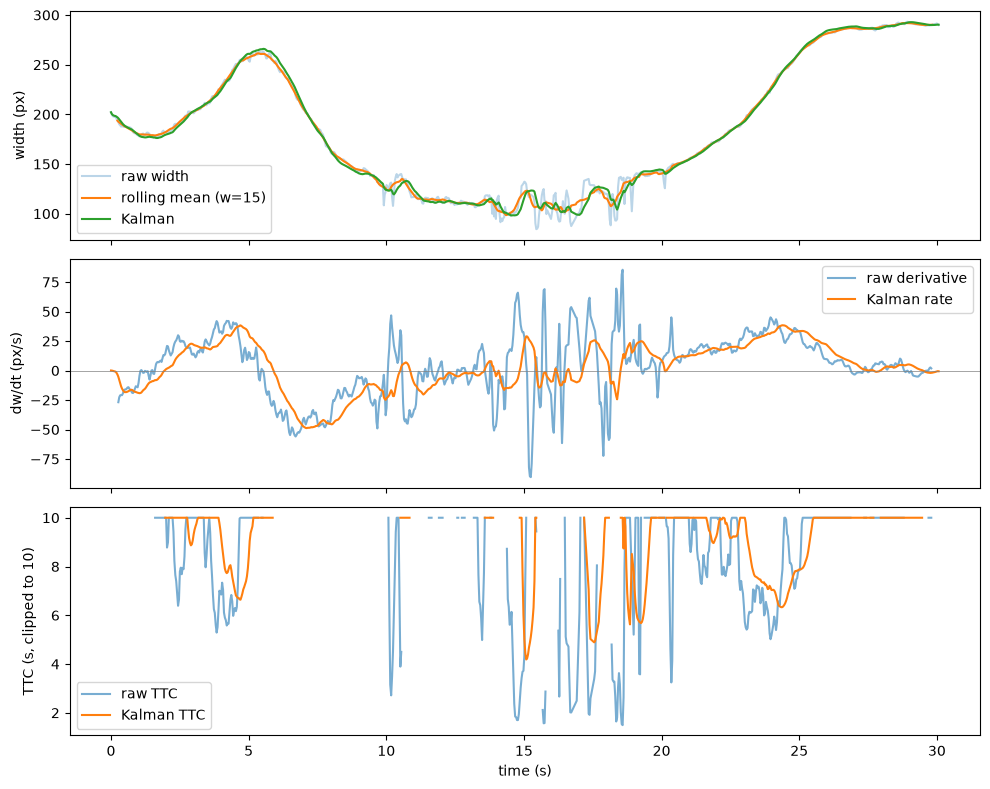

In [10]:
# --- Compare: raw rolling-mean derivative (window=15) vs. Kalman ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(car["time_s"], car["w"], alpha=0.3, label="raw width")
axes[0].plot(car["time_s"], car["w_smooth"], label="rolling mean (w=15)")
axes[0].plot(car["time_s"], car["w_kalman"], label="Kalman")
axes[0].set_ylabel("width (px)")
axes[0].legend()

axes[1].plot(car["time_s"], car["dw_dt"], alpha=0.6, label="raw derivative")
axes[1].plot(car["time_s"], car["rate_kalman"], label="Kalman rate")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("dw/dt (px/s)")
axes[1].legend()

axes[2].plot(car["time_s"], car["ttc"].clip(upper=10), alpha=0.6, label="raw TTC")
axes[2].plot(car["time_s"], car["ttc_kalman"].clip(upper=10), label="Kalman TTC")
axes[2].set_ylabel("TTC (s, clipped to 10)")
axes[2].set_xlabel("time (s)")
axes[2].legend()

plt.tight_layout()
plt.show()


current: sign flips=21, non-nan TTC frac=0.567
tighter: sign flips=10, non-nan TTC frac=0.599


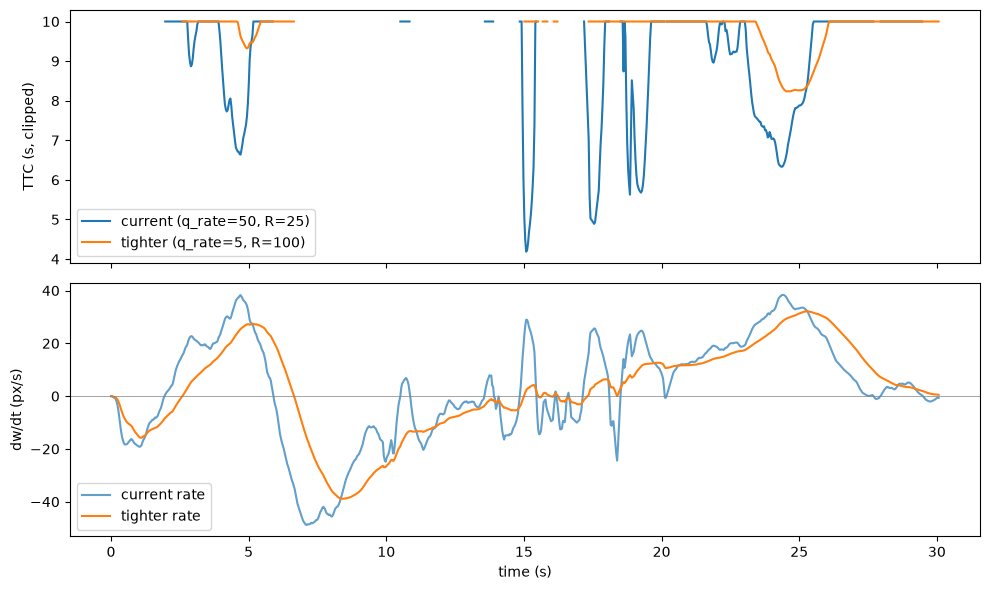

In [11]:
# --- Kalman filter, step 5: tune Q vs R and compare ---
#
# Wrap the loop as a function so we can try different (q_width, q_rate, r_meas)
# without copy-pasting the loop. Lower q_rate = trust momentum more (smoother,
# slower to react). Higher R = trust each individual measurement less.

def run_kalman(widths, times, q_width, q_rate, r_meas):
    x = np.array([widths[0], 0.0])
    P = np.eye(2) * 100.0
    H = np.array([[1.0, 0.0]])
    R = np.array([[r_meas]])
    n = len(widths)
    w_k = np.zeros(n)
    rate_k = np.zeros(n)
    w_k[0], rate_k[0] = x

    for i in range(1, n):
        dt = times[i] - times[i - 1]
        if dt <= 0:
            dt = 1 / 30
        F = np.array([[1.0, dt], [0.0, 1.0]])
        Q = np.array([[q_width * dt, 0.0], [0.0, q_rate * dt]])

        x = F @ x
        P = F @ P @ F.T + Q

        z = widths[i]
        y = z - (H @ x)[0]
        S = (H @ P @ H.T)[0, 0] + R[0, 0]
        K = (P @ H.T).flatten() / S

        x = x + K * y
        P = (np.eye(2) - np.outer(K, H)) @ P
        w_k[i], rate_k[i] = x

    ttc = np.full(n, np.nan)
    np.divide(w_k, rate_k, out=ttc, where=rate_k > 0)
    return w_k, rate_k, ttc


# Current vs a tighter tuning (less process noise on rate, more measurement noise)
w_k1, rate_k1, ttc_k1 = run_kalman(widths, times, q_width=1.0, q_rate=50.0, r_meas=25.0)
w_k2, rate_k2, ttc_k2 = run_kalman(widths, times, q_width=1.0, q_rate=5.0, r_meas=100.0)

for label, rate_k, ttc in [("current", rate_k1, ttc_k1), ("tighter", rate_k2, ttc_k2)]:
    flips = (np.sign(rate_k[1:]) != np.sign(rate_k[:-1])).sum()
    print(f"{label}: sign flips={flips}, non-nan TTC frac={np.mean(~np.isnan(ttc)):.3f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(times, np.clip(ttc_k1, 0, 10), label="current (q_rate=50, R=25)")
axes[0].plot(times, np.clip(ttc_k2, 0, 10), label="tighter (q_rate=5, R=100)")
axes[0].set_ylabel("TTC (s, clipped)")
axes[0].legend()

axes[1].plot(times, rate_k1, alpha=0.7, label="current rate")
axes[1].plot(times, rate_k2, label="tighter rate")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("dw/dt (px/s)")
axes[1].set_xlabel("time (s)")
axes[1].legend()

plt.tight_layout()
plt.show()


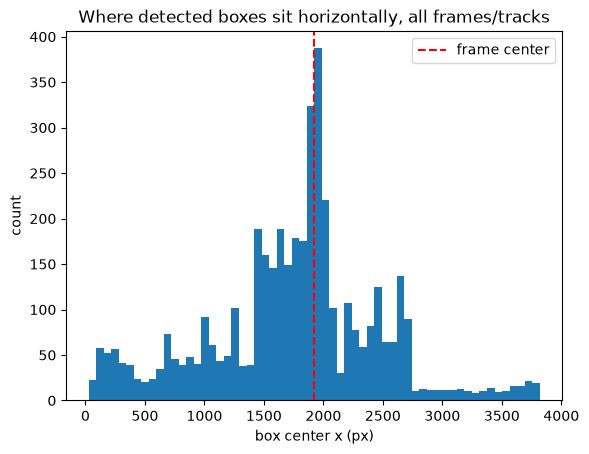

In [12]:
# --- Lead-vehicle selection, step 1: where do boxes actually sit horizontally? ---
#
# Source video is 3840x2160 (4K, see NOTES.md). Box center x tells us how
# far left/right of frame-center each detection is. If real lead-car
# detections cluster near the horizontal center, a center band is a
# reasonable "in my lane" proxy without needing real lane-line detection.

FRAME_WIDTH = 3840

all_boxes = df.copy()
all_boxes["cx"] = (all_boxes["x1"] + all_boxes["x2"]) / 2

plt.hist(all_boxes["cx"], bins=60)
plt.axvline(FRAME_WIDTH / 2, color="red", linestyle="--", label="frame center")
plt.xlabel("box center x (px)")
plt.ylabel("count")
plt.title("Where detected boxes sit horizontally, all frames/tracks")
plt.legend()
plt.show()


In [13]:
# --- Lead-vehicle selection, step 2: pick one box per frame ---
#
# "In my lane" = box center within a band around frame-center.
# Band width: +-10% of frame width each side. Originally tried +-15%, but
# that let a car that pulls up alongside while stopped (big AND briefly
# within 15% of center) get picked over the real lead car -- see step 6
# below for why. +-10% keeps that car out while still covering the real
# lead car's full range of horizontal jitter.
# Among boxes in the band, pick the largest by area (nearest).

BAND_HALF_WIDTH = 0.10 * FRAME_WIDTH
frame_center = FRAME_WIDTH / 2

all_boxes["area"] = (all_boxes["x2"] - all_boxes["x1"]) * (all_boxes["y2"] - all_boxes["y1"])
in_lane = all_boxes[(all_boxes["cx"] - frame_center).abs() < BAND_HALF_WIDTH]

lead_per_frame = (
    in_lane.loc[in_lane.groupby("frame")["area"].idxmax()]
    .sort_values("frame")[["frame", "time_s", "track_id", "area", "cx"]]
)

print("Frames with a lead-car candidate:", len(lead_per_frame), "/", df["frame"].nunique())
print("\nMost frequently selected track IDs:")
print(lead_per_frame["track_id"].value_counts().head(10))


Frames with a lead-car candidate: 820 / 902

Most frequently selected track IDs:
track_id
4      624
175    113
7       35
113     17
120     10
66       8
31       5
72       5
27       1
5        1
Name: count, dtype: int64


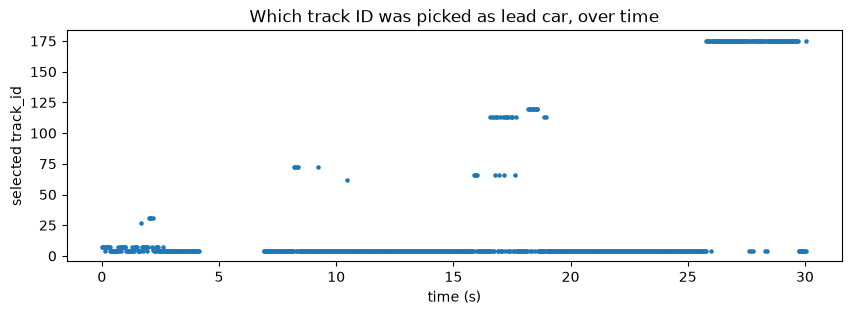

             min     max  count
track_id                       
5          2.202   2.202      1
7          0.000   2.603     35
27         1.668   1.668      1
31         2.002   2.169      5
62        10.477  10.477      1
66        15.883  17.618      8
72         8.208   9.243      5
113       16.583  18.952     17
120       18.185  18.585     10
175       25.792  30.063    113


In [14]:
# --- Lead-vehicle selection, step 3: is ID 94 a real switch, or noise? ---
#
# Plot which track_id got picked as lead, over time. If ID 94 is the same
# physical car re-acquired under a new ID during a tracking gap, it should
# show up as one contiguous stretch of time, not scattered throughout.

plt.figure(figsize=(10, 3))
plt.scatter(lead_per_frame["time_s"], lead_per_frame["track_id"], s=5)
plt.xlabel("time (s)")
plt.ylabel("selected track_id")
plt.title("Which track ID was picked as lead car, over time")
plt.show()

# Time range for each non-dominant ID, to check if they're contiguous
other = lead_per_frame[lead_per_frame["track_id"] != 4]
print(other.groupby("track_id")["time_s"].agg(["min", "max", "count"]))


In [15]:
# --- Lead-vehicle selection, step 4: exclude self-detections ---
#
# Correction to step 3's guess: checking the actual video showed ID 94 is
# NOT the same lead car re-acquired -- it's a self-detection of the dashcam
# car's own hood/dash, misclassified as a vehicle. Confirmed in the data:
# ID 94 boxes are ~5:1 width:height (a real car here averages ~1.26:1) and
# sit with their bottom edge at ~99.8% of frame height (glued to the
# bottom), vs. ~55.5% for the real lead car. Filter both properties out,
# not the track ID (IDs aren't stable run to run, so hardcoding one would
# only fix this specific clip).

MAX_ASPECT_RATIO = 2.5   # real cars here are ~1.2-1.5; well clear of self-detections at ~5.0
BOTTOM_MARGIN = 0.95     # exclude boxes whose bottom edge is in the bottom 5% of the frame

FRAME_HEIGHT = 2160

all_boxes["aspect"] = all_boxes["w"] / all_boxes["h"]
not_self = (all_boxes["aspect"] < MAX_ASPECT_RATIO) & (all_boxes["y2"] < BOTTOM_MARGIN * FRAME_HEIGHT)

in_lane_v2 = all_boxes[
    ((all_boxes["cx"] - frame_center).abs() < BAND_HALF_WIDTH) & not_self
]

lead_per_frame_v2 = (
    in_lane_v2.loc[in_lane_v2.groupby("frame")["area"].idxmax()]
    .sort_values("frame")[["frame", "time_s", "track_id", "area", "cx"]]
)

print("Frames with a lead-car candidate:", len(lead_per_frame_v2), "/", df["frame"].nunique())
print("\nMost frequently selected track IDs:")
print(lead_per_frame_v2["track_id"].value_counts().head(10))


Frames with a lead-car candidate: 820 / 902

Most frequently selected track IDs:
track_id
4      784
113     15
66      10
31       7
27       1
5        1
35       1
62       1
Name: count, dtype: int64


In [16]:
# --- Lead-vehicle selection, step 5: temporal stickiness (hysteresis) ---
#
# Rule: once a car is "the lead," keep it unless
#   (a) it's missing from the candidates for LOST_STREAK consecutive frames
#       (really gone, not just a 1-frame detection dropout), or
#   (b) a different car has been the single biggest candidate for
#       SWITCH_STREAK consecutive frames in a row (a sustained overtake,
#       not a 1-2 frame blip).
# This is a frame-by-frame loop (not vectorizable) because the decision at
# frame i depends on the running state built up from previous frames.

SWITCH_STREAK = 10  # ~0.33s at 30fps: how long a challenger must dominate before we switch
LOST_STREAK = 5      # ~0.17s: how long the current lead must be absent before we give up on it

by_frame = {f: g for f, g in in_lane_v2.groupby("frame")}
all_frames = sorted(all_boxes["frame"].unique())

current_lead = None
challenger_id, challenger_streak = None, 0
missing_streak = 0

lead_rows = []
for f in all_frames:
    cands = by_frame.get(f)
    if cands is None or len(cands) == 0:
        missing_streak += 1
        continue

    top = cands.loc[cands["area"].idxmax()]

    if current_lead is None:
        current_lead = top["track_id"]
        missing_streak = 0
        challenger_id, challenger_streak = None, 0
        lead_rows.append(top)
        continue

    lead_row = cands[cands["track_id"] == current_lead]

    if len(lead_row) == 0:
        # current lead not detected at all this frame
        missing_streak += 1
        if missing_streak >= LOST_STREAK:
            current_lead = top["track_id"]
            missing_streak = 0
            challenger_id, challenger_streak = None, 0
            lead_rows.append(top)
        # else: still waiting to see if it comes back; no row this frame
        continue

    missing_streak = 0

    if top["track_id"] == current_lead:
        challenger_id, challenger_streak = None, 0
        lead_rows.append(lead_row.iloc[0])
    else:
        if top["track_id"] == challenger_id:
            challenger_streak += 1
        else:
            challenger_id, challenger_streak = top["track_id"], 1

        if challenger_streak >= SWITCH_STREAK:
            current_lead = challenger_id
            challenger_id, challenger_streak = None, 0
            lead_rows.append(top)
        else:
            # challenger hasn't dominated long enough yet -- stick with current lead
            lead_rows.append(lead_row.iloc[0])

lead_hyst = pd.DataFrame(lead_rows)[["frame", "time_s", "track_id", "area", "cx"]]

print("Frames with a lead-car pick:", len(lead_hyst), "/", len(all_frames))
print("Unique track IDs picked:", lead_hyst["track_id"].nunique())
print(lead_hyst["track_id"].value_counts())


Frames with a lead-car pick: 793 / 902
Unique track IDs picked: 1
track_id
4    793
Name: count, dtype: int64


In [17]:
# --- Wiring step 1: turn the auto-selected lead into a width series ---
#
# Everything above (`car`) was built from a hardcoded `track_id == 4`.
# `lead_hyst` instead gives us, per frame, *which* track_id is the lead --
# that ID can in principle change over time. To feed the Kalman filter we
# need a single width-over-time series again, so: for each frame in
# lead_hyst, look up that frame's box width for whichever track_id was
# picked. This is just a merge, not new logic -- lead_hyst already has
# `area` but not `w`/`h` directly, so pull them back from all_boxes.

auto_lead = lead_hyst.merge(
    all_boxes[["frame", "track_id", "w", "h"]],
    on=["frame", "track_id"],
    how="left",
).sort_values("time_s").reset_index(drop=True)

print("auto_lead frames:", len(auto_lead), "/", len(all_frames))
print("unique track_ids in auto_lead:", auto_lead["track_id"].nunique())
print(auto_lead[["frame", "time_s", "track_id", "w"]].head())

# Sanity check vs. the old hardcoded-ID series: since lead_hyst is 100% ID 4
# on this clip, auto_lead's widths should match `car`'s widths on the
# frames both have in common (auto_lead has fewer frames -- it skips the
# frames where hysteresis had no candidate at all, e.g. during LOST_STREAK
# gaps -- `car` just uses every frame track_id 4 was independently detected).
common = auto_lead.merge(car[["frame", "w"]], on="frame", suffixes=("_auto", "_manual"))
print("\nFrames in common:", len(common))
print("Max width difference on common frames:", (common["w_auto"] - common["w_manual"]).abs().max())


auto_lead frames: 793 / 902
unique track_ids in auto_lead: 1
   frame  time_s  track_id      w
0      0   0.000         4  202.1
1      1   0.033         4  199.8
2      2   0.067         4  198.1
3      3   0.100         4  197.7
4      4   0.133         4  197.5

Frames in common: 793
Max width difference on common frames: 0.0


In [18]:
# --- Wiring step 2: does the auto-selected series need special handling? ---
#
# Two things could break the Kalman filter here that don't exist when the
# track_id is hardcoded:
#   1. A real ID switch (different physical car becomes "lead") -> width
#      would jump discontinuously for a fake reason, not a real distance change.
#   2. Missing frames (hysteresis had zero in-band candidates) -> a bigger
#      gap between consecutive measurements than the usual 1/30s.
#
# On this clip, (1) doesn't happen -- auto_lead is 100% track_id 4, confirmed
# above. For (2): checking the actual frame numbers, the biggest gap is 83
# frames (2.77s) around t=4.1-6.9s. Looking at the raw boxes in that window,
# ID 4 was detected continuously the whole time -- it just drifted left of
# the 10% band (cx down to ~1430px vs the band's edge at 1536px, likely the
# road curving) and came back. Not a detection failure, just outside the
# "in my lane" definition for a couple seconds.
#
# This doesn't need a fix: the Kalman loop already scales Q by dt (see step
# 2 of the filter build), specifically so a bigger gap between measurements
# makes the filter trust its own prediction less. That was built in from the
# start for exactly this situation. Confirm the gap distribution here so
# it's on record, not just asserted.

frame_gaps_auto = auto_lead["frame"].diff()
print("Frame gap distribution in auto_lead:")
print(frame_gaps_auto.value_counts().sort_index())
print("\nLargest gap:", frame_gaps_auto.max(), "frames =", frame_gaps_auto.max() / 30, "s")


Frame gap distribution in auto_lead:
frame
1.0     776
2.0       9
3.0       2
4.0       2
5.0       2
83.0      1
Name: count, dtype: int64

Largest gap: 83.0 frames = 2.7666666666666666 s


Auto-lead Kalman: sign flips: 21
Auto-lead Kalman: non-nan TTC fraction: 0.5598991172761665


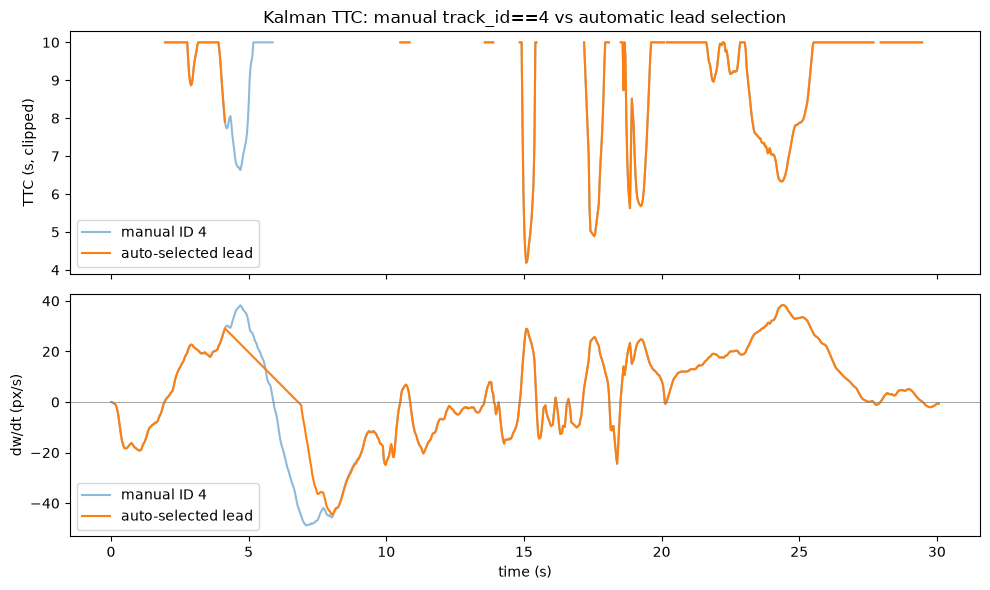


Closing events (Kalman TTC < 8s), auto-selected lead:
   start_s   end_s  n_frames
0    4.137   4.137         1
1   14.948  15.382        14
2   17.351  17.851        11
3   18.719  18.852         5
4   18.986  19.486        16
5   23.290  25.158        57


In [19]:
# --- Wiring step 3: run the Kalman filter on the auto-selected series ---
#
# Same run_kalman() function from the tuning step, just fed auto_lead's
# widths/times instead of the manual car['w']/car['time_s']. Tuning stays
# at the values we already settled on (q_width=1, q_rate=50, R=25).

auto_widths = auto_lead["w"].to_numpy()
auto_times = auto_lead["time_s"].to_numpy()

w_auto_k, rate_auto_k, ttc_auto_k = run_kalman(auto_widths, auto_times, q_width=1.0, q_rate=50.0, r_meas=25.0)

auto_lead["w_kalman"] = w_auto_k
auto_lead["rate_kalman"] = rate_auto_k
auto_lead["ttc_kalman"] = ttc_auto_k

print("Auto-lead Kalman: sign flips:", (np.sign(rate_auto_k[1:]) != np.sign(rate_auto_k[:-1])).sum())
print("Auto-lead Kalman: non-nan TTC fraction:", np.mean(~np.isnan(ttc_auto_k)))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(car["time_s"], car["ttc_kalman"].clip(upper=10), alpha=0.5, label="manual ID 4")
axes[0].plot(auto_lead["time_s"], np.clip(ttc_auto_k, 0, 10), label="auto-selected lead")
axes[0].set_ylabel("TTC (s, clipped)")
axes[0].legend()
axes[0].set_title("Kalman TTC: manual track_id==4 vs automatic lead selection")

axes[1].plot(car["time_s"], car["rate_kalman"], alpha=0.5, label="manual ID 4")
axes[1].plot(auto_lead["time_s"], rate_auto_k, label="auto-selected lead")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("dw/dt (px/s)")
axes[1].set_xlabel("time (s)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Same validation as the manual-ID version: group consecutive below-8s-TTC
# frames into discrete "events" (start/end time, frame count) instead of a
# raw frame dump, so it's directly comparable to the earlier results table
# in NOTES.md (4.14-4.94s, 14.95-15.35s, 18.72-19.35s, 23.29-25.16s).
below = auto_lead["ttc_kalman"] < 8
event_id = (below != below.shift(fill_value=False)).cumsum()
events = (
    auto_lead[below]
    .groupby(event_id[below])
    .agg(start_s=("time_s", "min"), end_s=("time_s", "max"), n_frames=("time_s", "size"))
    .reset_index(drop=True)
)
print("\nClosing events (Kalman TTC < 8s), auto-selected lead:")
print(events)
